In [1]:
%load_ext autoreload
%autoreload 2

In [5]:
from tools.utils import *
import pandas as pd
import numpy as np
import seaborn as sns
from itertools import combinations
from collections import Counter
from pathlib import Path
from sklearn.cluster import KMeans
from scipy.interpolate import interp1d
import scipy.spatial as sp
from matplotlib import pyplot as plt
sns.set()

In [6]:
processed_data_dir = Path('processed_data/tous')

In [7]:
embeddings = np.loadtxt(processed_data_dir / 'embedding_bge.tsv')
metadata = pd.read_csv(processed_data_dir / 'metadata.tsv',sep='\t')
print(len(embeddings), len(metadata))
# 84621 84621

124495 124495


In [8]:
embeddings.shape

(124495, 1024)

In [9]:
metadata.columns

Index(['platform', 'year', 'sentence', 'sentence_processed'], dtype='object')

In [10]:
metadata.platform.nunique()

42

In [11]:
metadata.drop_duplicates(subset=['platform', 'year', 'sentence'], inplace=True)
metadata.shape

(118457, 4)

# Compare two contracts 

Based on the platform name and date

In [12]:
metadata.platform.value_counts()

platform
venmo          29426
grindr          7859
match           6285
twitch          4637
bumble          4473
fb              4305
zoom            3902
capcut          3875
tumblr          3429
snapchat        3186
meetup          2953
wechat          2928
patreon         2847
linkedin        2842
reddit          2546
myspace         2467
onlyfans        2164
hinge           2056
twitter         2011
discord         1980
tinder          1868
nextdoor        1817
youtube         1636
tiktok          1602
imo             1548
pinterest       1531
google          1432
viber           1208
substack        1192
gab             1071
instagram       1065
gettr           1023
bluesky          942
truthsocial      883
faceapp          791
likee            594
whatsapp         578
medium           411
bereal           362
telegram         347
threads          303
signal            82
Name: count, dtype: int64

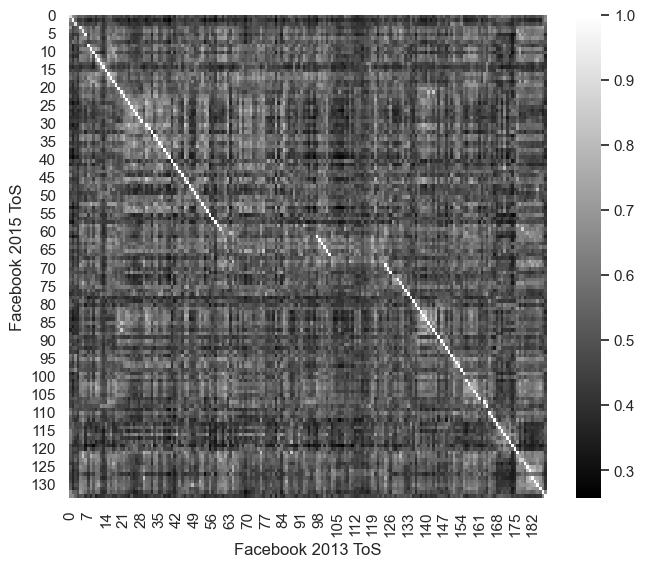

In [14]:
platform_1 = 'twitter'
platform_2 = 'twitter'
year_1 = 20160101
year_2 = 20160901

platform_1 = 'fb'
platform_2 = 'fb'
year_1 = 20131101 # 20180401 #2013110
year_2 = 20150101 #20150101 20190701

# platform_1 = 'Google'
# platform_2 = 'Google'
# year_1 =20051101 #20051101
# year_2 = 20070401 #20070401



idx_1 = list(metadata[(metadata.platform==platform_1) & (metadata.year ==year_1)].index)
idx_2 = list(metadata[(metadata.platform==platform_2) & (metadata.year ==year_2)].index)
#mult = cosine_similarity(embeddings[idx_1,:],embeddings[idx_2,:])
mult = 1 - sp.distance.cdist(embeddings[idx_2,:], embeddings[idx_1,:], 'cosine')
sns.set(rc={'figure.figsize':(7.7,6.27)})
heatmap = sns.heatmap(mult, cmap='gray')
plt.ylabel('Facebook 2015 ToS')
plt.xlabel('Facebook 2013 ToS')
fig = heatmap.get_figure()
fig.savefig("figures/jels/Figure_5_gray.png", dpi=300, bbox_inches='tight') 

In [15]:
len(idx_1), len(idx_2), mult.shape

(188, 134, (134, 188))

In [16]:
print(sum(mult.max(axis=0) > 0.93), sum(mult.max(axis=0) < 0.93))
print(sum(mult.max(axis=1) < 0.93),sum(mult.max(axis=1) >= 0.93))


117 71
17 117


/var/folders/d2/ydv0grbd38985h6_95t0vdjw0000gp/T/ipykernel_30472/2280298480.py:1: UserWarning: 'color' and 'colormap' cannot be used simultaneously. Using 'color'
  ax = pd.Series(mult.max(axis=0)).plot(ylim=(0,1.02), color='black', cmap='gray')
/var/folders/d2/ydv0grbd38985h6_95t0vdjw0000gp/T/ipykernel_30472/2280298480.py:1: UserWarning: 'color' and 'colormap' cannot be used simultaneously. Using 'color'
  ax = pd.Series(mult.max(axis=0)).plot(ylim=(0,1.02), color='black', cmap='gray')


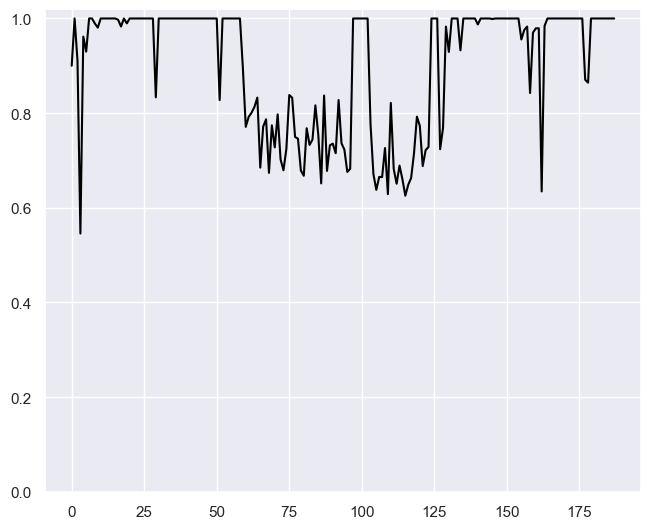

In [17]:
ax = pd.Series(mult.max(axis=0)).plot(ylim=(0,1.02), color='black', cmap='gray')
#ax.axhline(0.93, c='r')
fig = ax.get_figure()
fig.savefig("figures/jels/Figure_6_gray.png", dpi=300, bbox_inches='tight')

In [18]:
# metadata['year'] = metadata.year.apply(lambda x: str(x)[:4] + "0101").astype(int)
# metadata.dropna(subset=['platform','sentence_processed','year'], inplace=True)
# metadata.shape

In [19]:
# metadata['year_int'] = metadata.year.apply(lambda x: str(x)[:4]).astype(int)
# platform_last_yearly = metadata.groupby(['platform','year_int'])['year'].unique().apply(lambda x: x[0]).reset_index()[['platform','year']]
# metadata = metadata.merge(platform_last_yearly[['platform', 'year']], on=['platform', 'year'], how='inner')
# metadata

In [20]:
platforms = ['twitter','fb','instagram']
#platforms = ['google']#,'youTube']
#platforms = ['PayPal','Venmo']
threshold = .93
result_df = compare_timelines(metadata, embeddings,platforms,threshold)

100%|██████████| 7/7 [00:00<00:00, 39.67it/s]


In [21]:
result_df.replace({'platform': {'fb':'Facebook',
                             'twitter':'Twitter',
                             'instagram':'Instagram',}}, inplace=True)

/Users/kasparbeelen/anaconda3/envs/tou/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/kasparbeelen/anaconda3/envs/tou/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


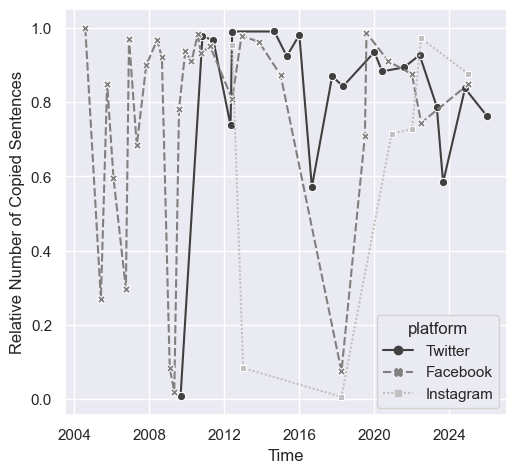

In [22]:
result_df = result_df[(result_df.copied != 592 )& (result_df.index != 'Facebook')]

sns.set(rc={'figure.figsize':(5.7,5.27)})
ax = sns.lineplot(x=result_df.index,y='rel_copied',
                hue='platform',
                style="platform",
                markers=True,
                data=result_df,
                palette='gray'
            )

ax.set(
    xlabel="Time",
    ylabel="Relative Number of Copied Sentences",
)
 
fig = ax.get_figure()
fig.savefig("figures/jels/Figure_8_right_gray.png", dpi=300, bbox_inches='tight')

/Users/kasparbeelen/anaconda3/envs/tou/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/kasparbeelen/anaconda3/envs/tou/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


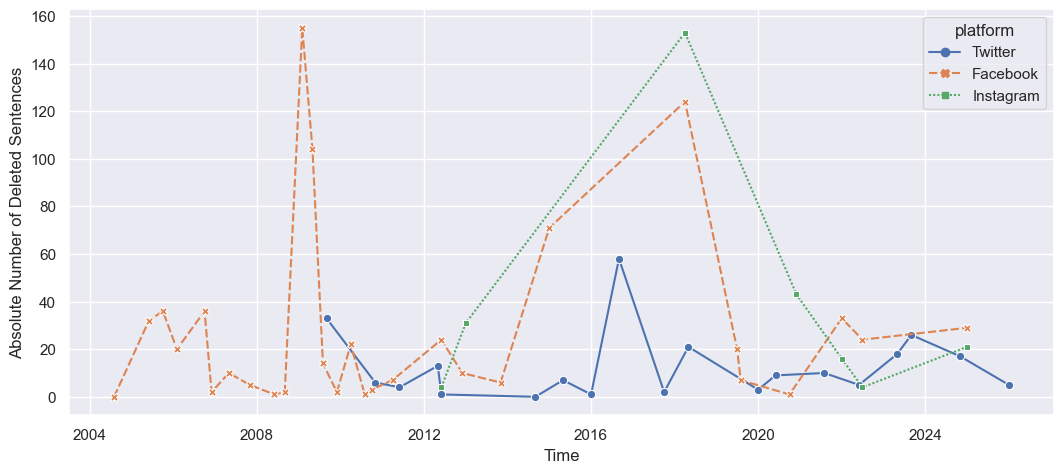

In [17]:
sns.set(rc={'figure.figsize':(12.7,5.27)})
ax =sns.lineplot(x=result_df.index,
                y='deletions',
                hue='platform',
                style="platform",
                markers=True,
                data=result_df,
                #palette='gray'
            )

ax.set(
    xlabel="Time",
    ylabel="Absolute Number of Deleted Sentences",
)

fig = ax.get_figure()
fig.savefig("figures/jels/Figure_9_top.png", dpi=300, bbox_inches='tight')

/Users/kasparbeelen/anaconda3/envs/tou/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/kasparbeelen/anaconda3/envs/tou/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


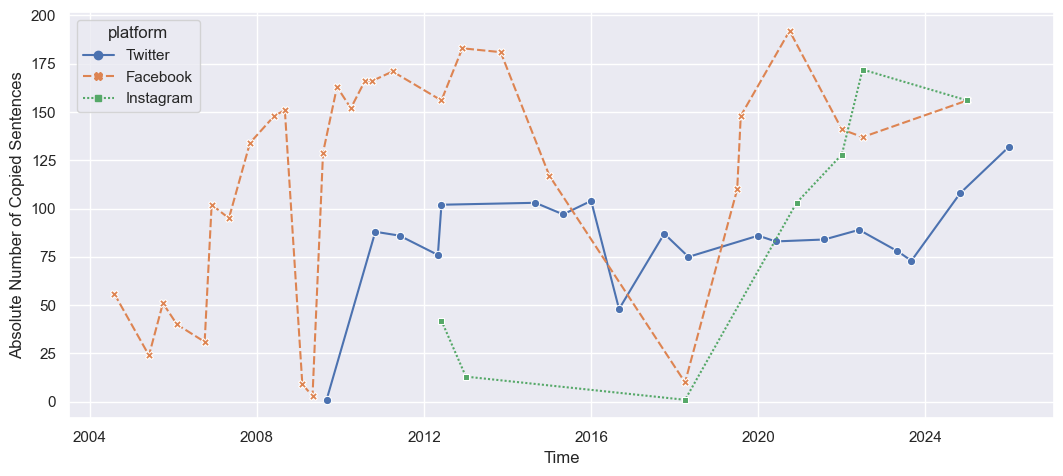

In [23]:
sns.set(rc={'figure.figsize':(12.7,5.27)})
ax =sns.lineplot(x=result_df.index,
                y='copied',
                hue='platform',
                style="platform",
                markers=True,
                data=result_df,
                #palette='gray'
            )

ax.set(
    xlabel="Time",
    ylabel="Absolute Number of Copied Sentences",
)

fig = ax.get_figure()
fig.savefig("figures/jels/Figure_9_top.png", dpi=300, bbox_inches='tight')

In [24]:
# result_df = result_df.sort_index(ascending=True)

# sns.set(rc={'figure.figsize':(12.7,5.27)})
# result_df['time'] = result_df.index.copy()
# result_df['time'] = result_df['time'].apply(lambda x: datetime(int(str(x)[:4]), 1, 1))

# ax = sns.lineplot(x='time',y='rel_added',
#                 hue='platform',
#                 style="platform",
#                 markers=True,
                
#                 data=result_df,
#                 alpha=.9

#             )
# ax.set(
#     xlabel="Time",
#     ylabel="Relative Number of Added Sentences",
# )

# # platforms_col = [('blue','fb'),('darkorange','twitter'),('green','instagram')]#,'google']#,'youTube']#,'PayPal','Venmo']
# # for i,(col,p) in enumerate(platforms_col):
# #         for xc in metadata[metadata.platform==p].year.unique():
# #          if datetime(int(str(xc)[:4]), 1, 1) >=  result_df.time.min() and datetime(int(str(xc)[:4]), 1, 1) <= result_df.time.max():
# #              ax.axvline(x=datetime(int(str(xc)[:4]), 1, 1)+pd.Timedelta(days=i*30), color=col, linestyle='-', alpha=.5, linewidth=2.5)
# #         #ax.axvline(x=xc, color=col, linestyle='--', alpha=.2)
# # # 👇 Show fewer ticks (e.g., one per year)
# import matplotlib.dates as mdates

# ax.xaxis.set_major_locator(mdates.YearLocator(1))   # every 1 year
# ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
# ax.tick_params(axis='x', rotation=90, labelsize=15)

In [ ]:
# from datetime import datetime, time 
# dt = datetime.combine(result_df.index.min(), time())
# dt

datetime.datetime(2004, 8, 1, 0, 0)

In [ ]:
# result_df_without_min = result_df[result_df.rel_added > result_df.rel_added.min()]

In [25]:
# sns.set(rc={'figure.figsize':(12.7,5.27)})
# sns.lineplot(x=result_df_without_min.index,
#                 y='rel_added',
#                 hue='platform',
#                 style="platform",
#                 markers=True,
#                 data=result_df_without_min
#             )

In [ ]:
platforms = list(metadata.platform.unique())
threshold = .93
result_df = compare_timelines(metadata, embeddings, platforms,threshold)


100%|██████████| 7/7 [00:00<00:00, 31.66it/s]
0it [00:00, ?it/s]
100%|██████████| 16/16 [00:00<00:00, 20.77it/s]


In [27]:
# import matplotlib.pyplot as plt
# fig, axes = plt.subplots(1, 3, figsize=(15, 4))
# bins = np.linspace(0, 1, 21)
# # Plot histograms for each column
# axes[0].hist(result_df["rel_additions"], bins=20, color="skyblue", edgecolor="black")
# axes[0].set_title("Additions")

# axes[1].hist(result_df["rel_deletions"], bins=20, color="salmon", edgecolor="black")
# axes[1].set_title("Deletions")

# axes[2].hist(result_df["rel_copied"], bins=20, color="lightgreen", edgecolor="black")
# axes[2].set_title("Copies")

# plt.tight_layout()
# plt.show()

In [28]:
# import numpy as np
# bins = np.linspace(0, 1, 21)
# counts, divisions = np.histogram(result_df.rel_deletions, bins=bins) # rel_additions

In [29]:
# print((counts / sum(counts)).round(2))
# print((counts[divisions[1:] > 0.5] / sum(counts)).round(2).sum())

In [ ]:
# result_df['year'] = [i.year for i in result_df.index]

In [32]:
# result_df['additions'] +  result_df['copied'] == result_df['length']

In [30]:
# result_df.deletions.mean()

In [31]:
# result_df.additions.mean()

In [ ]:
# result_df = result_df[result_df.deletions < 500]

In [33]:
# result_df['plasticity'] = result_df['additions'] + result_df['deletions']
# #result_df['plasticity_rel'] = result_df['plasticity'] / result_df['copied']

In [34]:
# import matplotlib.pyplot as plt
# order = 3
# fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# sns.regplot(data=result_df.astype({'year': int, 'additions': float}), x='year', y='additions', ax=axes[0],order=order)
# sns.regplot(data=result_df.astype({'year': int, 'deletions': float}), x='year', y='deletions', ax=axes[0], color='orange',order=order)
# axes[0].set_title('Additions (blue) and Deletions (orange) (abs) ')


# sns.regplot(data=result_df.astype({'year': int, 'plasticity': float}), x='year', y='plasticity', ax=axes[1],order=order)
# axes[1].set_title('Plasticity (abs)')

# sns.regplot(data=result_df.astype({'year': int, 'copied': float}), x='year', y='copied', ax=axes[2], order=order)
# axes[2].set_title('Copied (abs)')

# plt.tight_layout()
# plt.show()

In [35]:
# sns.set(rc={'figure.figsize':(12.7,5.27)})
# platforms = ['twitter','fb','instagram']
# #platforms = ['Google']#,'YouTube']
# #platforms = ['PayPal','Venmo']
# df_plat = result_df[result_df.platform.isin(platforms)]
# variable = 'plasticity' #'rel_copied' #'rel_deletions' # 'plasticity'
# from collections import OrderedDict

# df_plat.replace({'platform': OrderedDict([('twitter', 'Twitter'),('fb', 'Facebook'),  ('instagram', 'Instagram')])}, inplace=True)

# g= sns.lineplot(x=df_plat.index,y=variable,
#                 hue='platform',
#                 hue_order=['Twitter', 'Facebook', 'Instagram'],
#                 style="platform",
#                 markers=True,
#                 linewidth=2.5,
#                 legend=True,
#                 palette='gray',
#                 data=df_plat
#             )
# g.set(ylim=(0, None))




# ax = sns.lineplot(x=result_df.index,y=variable,
#                 style="platform",
#                 linewidth=0.25,
#                 markers=False,
#                 legend=False,
#                 color='gray',
#                 data=result_df
#             )

# ax.set(
#     xlabel="Time",
#     ylabel="Absolute Plasticity",
# )

# # df_avg = result_df.groupby(result_df.index)[variable].mean()#.rolling(window=3, center=False).mean().reset_index(level=0, drop=True)
# # sns.lineplot(x=df_avg.index,y=df_avg.values)
# df_avg = result_df.groupby(result_df.year)[variable].mean()#.rolling(window=3, center=False).mean().reset_index(level=0, drop=True)
# # convert integer year index to datetime (Jan 1 of that year)
# df_avg_dt = df_avg.copy()
# df_avg_dt.index = pd.to_datetime(df_avg_dt.index.astype(str), format='%Y')
# df_avg_dt.index.name = 'date'

# # quick check
# df_avg_dt.head()
# plast =sns.lineplot(x=df_avg_dt.index,y=df_avg_dt.values,linewidth=.5, color='black', label='average')
# fig = plast.get_figure()
# fig.savefig("figures/jels/Figure_10_gray.png", dpi=300, bbox_inches='tight')
# # sns.lineplot(x=df_avg.index,y=df_avg.values,
# #                 linewidth=.75,
# #                 color='red',
# #                 label='average'
# #            )



In [36]:
# import matplotlib.pyplot as plt

# order = 3

# result_df['rel_plasticity'] = result_df['rel_additions'] + result_df['rel_deletions']

# fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# sns.regplot(data=result_df.astype({'year': int, 'rel_additions': float}), x='year', y='rel_additions', ax=axes[0], order=order)
# sns.regplot(data=result_df.astype({'year': int, 'rel_deletions': float}), x='year', y='rel_deletions', ax=axes[0], color='orange', order=order)
# axes[0].set_title('Additions (blue) and Deletions (orange) (rel) ')

# sns.regplot(data=result_df.astype({'year': int, 'rel_plasticity': float}), x='year', y='rel_plasticity', ax=axes[1], order=order)
# axes[1].set_title('Plasticity (rel)')

# sns.regplot(data=result_df.astype({'year': int, 'rel_copied': float}), x='year', y='rel_copied', ax=axes[2], order=order)
# axes[2].set_title('Copied (rel)')

# plt.tight_layout()
# plt.show()

<Axes: xlabel='rel_copied', ylabel='platform'>

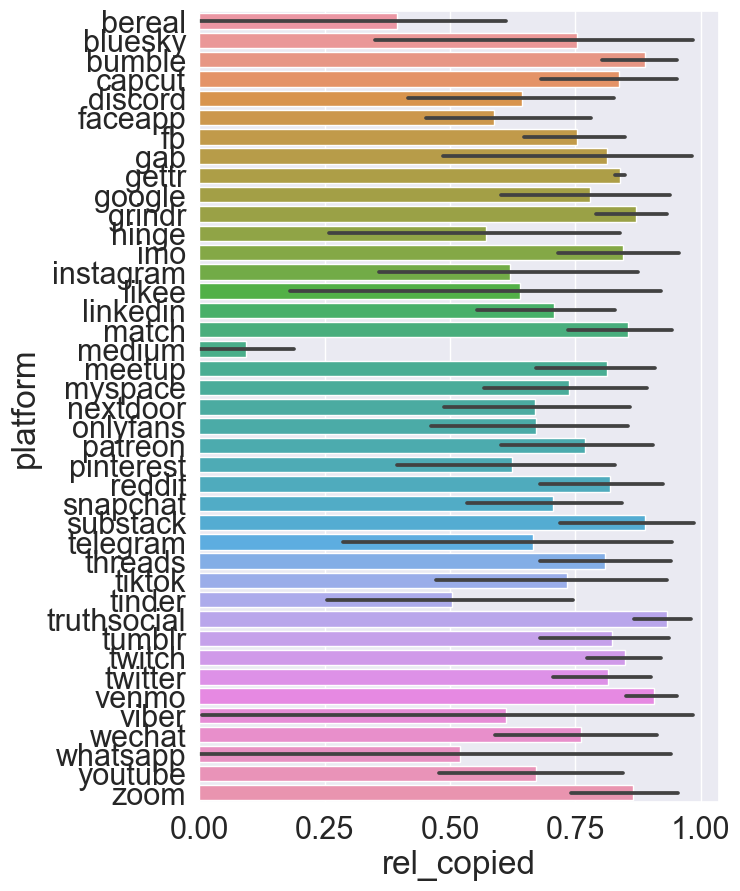

In [37]:
sns.set(rc={'figure.figsize':(6.7,10.27)})
sns.set(font_scale=2)
result_df= result_df.sort_values(by='platform')
sns.barplot(y='platform',x='rel_copied',data=result_df)

<Axes: xlabel='rel_additions', ylabel='platform'>

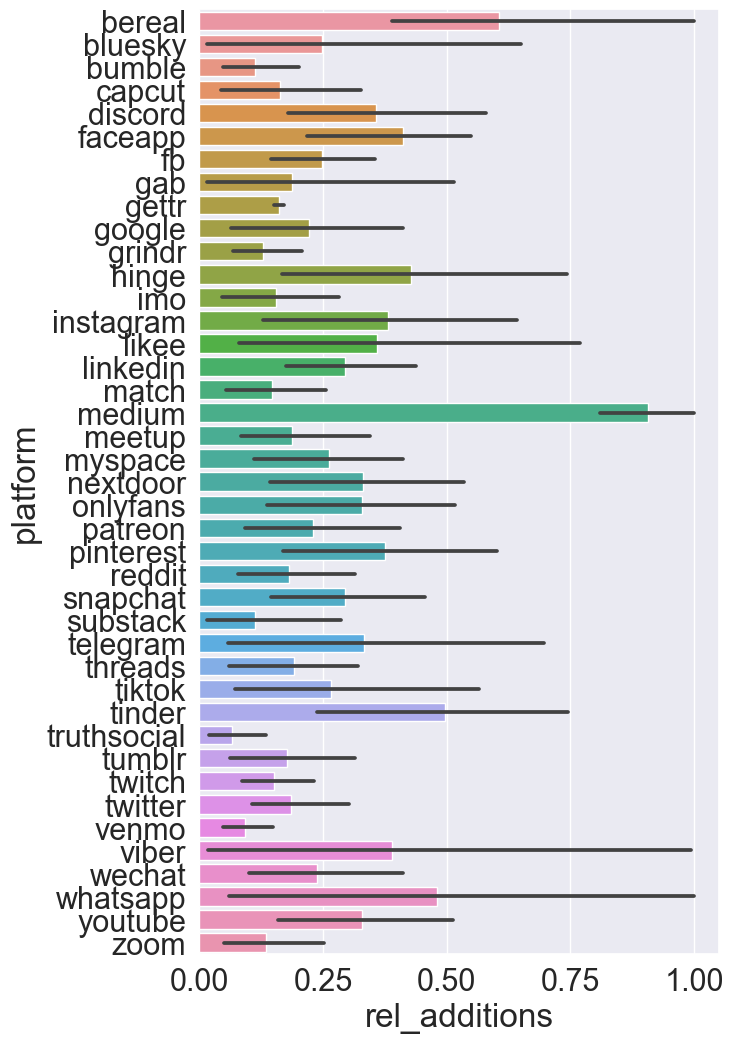

In [38]:
sns.set(rc={'figure.figsize':(6.7,12.27)})
sns.set(font_scale=2)
result_df= result_df.sort_values(by='platform')
sns.barplot(y='platform',x='rel_additions',data=result_df)

<Axes: xlabel='rel_deletions', ylabel='platform'>

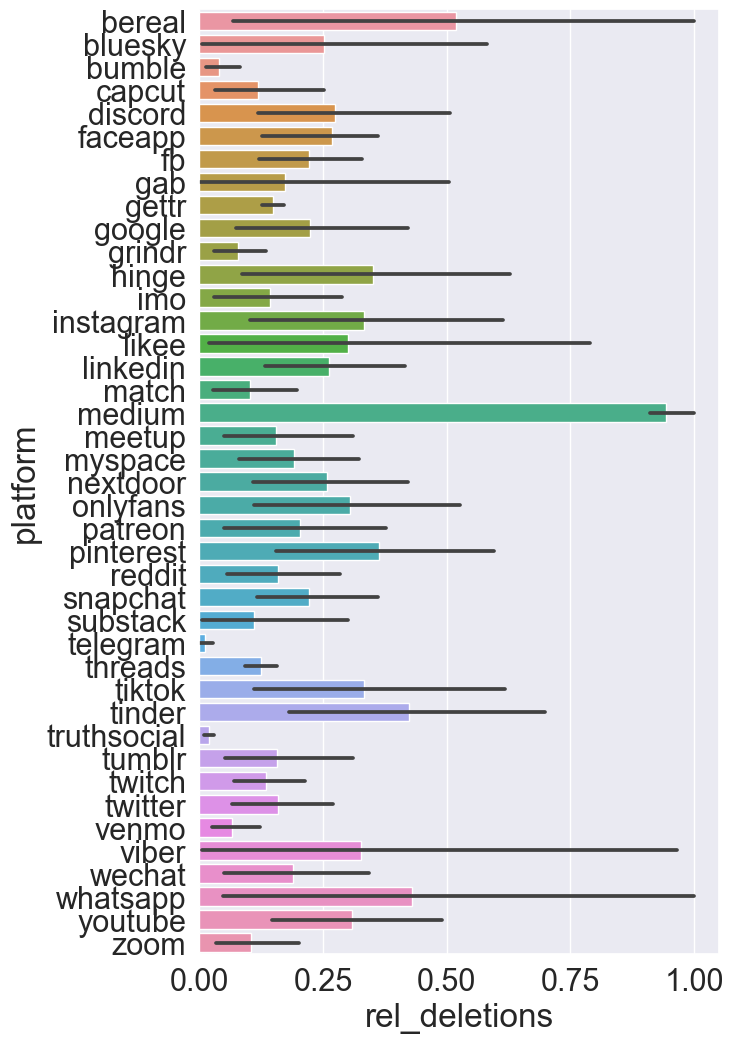

In [39]:
sns.set(rc={'figure.figsize':(6.7,12.27)})
sns.set(font_scale=2)
result_df= result_df.sort_values(by='platform')
sns.barplot(y='platform',x='rel_deletions',data=result_df)

# Clustering

In [40]:
# platforms = list(metadata.platform.unique())
# platforms.remove('PayPal')
# print(platforms)

In [41]:
# threshold = .93
# result_df = compare_timelines(metadata, embeddings, platforms,threshold)

In [42]:

# new_length = 100  # Define the new length
# interp_funcs = [interp1d(np.linspace(0, 1, len(p)), p) for p in result_df.past_projection.values]
# matrix = np.array([interp(np.linspace(0, 1, new_length)) for interp in interp_funcs])
# matrix.shape

In [43]:
# matrix_bin = (matrix > 0.93).astype(int)
# matrix_bin.shape

In [44]:
# pd.Series(np.where(matrix_bin < 1)[1]).plot(kind='hist', bins=100, ylim=(35,75))

In [45]:
# counts, division = np.histogram(np.where(matrix_bin < 1)[1], bins=np.linspace(0, 100, 101))

In [46]:
# pd.Series(counts).plot(alpha=0.5)
# pd.Series(counts).rolling(window=10).mean().plot()

In [47]:

# sorted_matrix = matrix_bin[np.argsort(matrix_bin.sum(axis=1))]
# sns.set(rc={'figure.figsize':(4.7,4.27)})
# sns.heatmap(sorted_matrix, cmap="YlGnBu", cbar=False, yticklabels=False)

In [50]:
# import numpy as np
# import matplotlib.pyplot as plt
# from tslearn.clustering import TimeSeriesKMeans



# # Number of clusters
# n_clusters = 6

# # DTW-based KMeans (soft-DTW is smoother and differentiable)
# model = TimeSeriesKMeans(n_clusters=n_clusters, 
#                          metric="dtw", 
#                          max_iter=10, 
#                          random_state=42)

# labels = model.fit_predict(matrix)

# # Print cluster assignments
# # for i, label in enumerate(labels):
# #     print(f"Timeline {i} -> Cluster {label}")

# # Visualize clusters
# plt.figure(figsize=(12, 6))
# for cluster_id in range(n_clusters):
#     plt.subplot(1, n_clusters, cluster_id + 1)
#     for ts, lbl in zip(matrix, labels):
#         if lbl == cluster_id:
#             plt.plot(ts.ravel(), alpha=0.5)
#     plt.plot(model.cluster_centers_[cluster_id].ravel(), color="black", linewidth=2)
#     plt.title(f"Cluster {cluster_id}")
# plt.tight_layout()
# plt.show()


In [51]:

# n_clusters = 3
# kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init="auto").fit(matrix)

In [49]:
# freqs = dict(Counter(kmeans.labels_))
# print(sum(freqs.values()))
# freqs = {k: round(v/ sum(freqs.values()),2) for k,v in freqs.items()}
# freqs

In [52]:
# xlabs= {2: 'Shake-up',
# 0: 'Cosmetic changes',
# 1: 'Structured rewrite'}
# new_dict = {xlabs[k]: v for k,v in dict(Counter(kmeans.labels_)).items()}
# pd.Series(new_dict).plot(kind='bar',width=.8,figsize=(4,5))

In [53]:
# pd.Series(new_dict) / sum(pd.Series(new_dict)) * 100

In [54]:
# for i in range(n_clusters):
#     pd.Series(np.mean(matrix[np.where(kmeans.labels_==i)],axis=0)).rolling(3).mean().plot()


In [55]:
# target_lab = 2
# pd.Series(np.mean(matrix[np.where(kmeans.labels_==target_lab)],axis=0)).rolling(3).mean().plot(color='red')
# for a in matrix[np.where(kmeans.labels_==target_lab)]:
#     pd.Series(a).plot(color='grey', alpha=.2)

In [56]:
# idx = np.where(kmeans.labels_==target_lab)[0][10]
# print(idx)
# sns.heatmap(result_df.iloc[idx].matrix)

In [57]:
# result_df['cluster_labels'] = kmeans.labels_
# by_platform = result_df.groupby(['platform','cluster_labels'])['platform'].count()#.reset_index()
# (by_platform.unstack(0) / by_platform.unstack(0).sum(axis=0)).T.plot(kind='bar', width=.75, figsize=(12,6))


In [58]:
# result_df['date'] = result_df.index
# result_df['year'] = result_df['date'].apply(lambda x: x.year)
# by_year = result_df.groupby(['year','cluster_labels'])['platform'].count()#.reset_index()
# (by_year.unstack(0) / by_year.unstack(0).sum(axis=0)).T.fillna(.0).plot(kind='bar', width=.75, figsize=(16,6))


# Convergence

In [59]:
#results.pop('bumle')
metadata.replace({'platform': {'fb':'Facebook',
                               'tinder': 'Tinder',
                             'twitter':'Twitter',
                             'whatsapp':'WhatsApp',
                             'myspace':'MySpace',
                             'paypal':'PayPal',
                             'venmo':'Venmo',
                             'ebay':'eBay',
                             'match':'Match',
                             'hinge':'Hinge',
                             'bumble':'Bumble',
                             'grindr':'Grindr',
                             'faceapp': 'FaceApp',
                             'instagram':'Instagram',}}, inplace=True)

In [60]:
platforms = list(metadata.platform.unique()); platforms

['Twitter',
 'truthsocial',
 'Bumble',
 'gettr',
 'discord',
 'pinterest',
 'Match',
 'MySpace',
 'google',
 'substack',
 'medium',
 'nextdoor',
 'Grindr',
 'tumblr',
 'youtube',
 'Venmo',
 'wechat',
 'imo',
 'gab',
 'onlyfans',
 'Facebook',
 'viber',
 'threads',
 'capcut',
 'patreon',
 'bluesky',
 'telegram',
 'reddit',
 'zoom',
 'FaceApp',
 'likee',
 'Hinge',
 'meetup',
 'Tinder',
 'tiktok',
 'twitch',
 'Instagram',
 'signal',
 'bereal',
 'snapchat',
 'WhatsApp',
 'linkedin']

In [61]:
metadata['date'] = metadata.year.apply(lambda x:datetime.strptime(str(x), "%Y%m%d").date() )

# platform_t = 'instagram'
# platform_c = 'fb'

# platform_t = 'YouTube'
# platform_c = 'Google'

# platform_t = 'Venmo'
# platform_c = 'PayPal'



In [62]:

results = defaultdict(dict)
#platforms = ['Tinder',"Match",'Bumble','Grindr','Hinge']#,'Instagram']#,'Google','YouTube','PayPal','Venmo']
for i,j in tqdm(list(combinations(platforms,r=2))):
    #if i == 'Bumble' or j == 'Bumble':
    results[i][j] = convergence(metadata, embeddings, i,j,threshold=.93)
    results[j][i] = convergence(metadata, embeddings, j,i,threshold=.93)
    

100%|██████████| 861/861 [17:47<00:00,  1.24s/it]


In [63]:
len(results.keys())

42

In [64]:
platform_target = 'Facebook'
#compare_to =[ ('green','Instagram'),('red','WhatsApp'),('orange','MySpace')]
#compare_to =[ ('darkgray','Instagram'),('black','WhatsApp'),('lightgray','MySpace')]


# platform_target = 'Google'
# compare_to = [('green','YouTube'),('red','Twitter')]

platform_target = 'PayPal'
#compare_to = [('green','Venmo'), ('red','eBay')]
#compare_to = [('gray','Venmo'), ('black','eBay')]

platform_target = 'Match'
compare_to = [('green','Bumble'), ('red','Hinge'),('orange','Grindr'),('blue','Tinder')] # ,('blue','faceapp')
#compare_to = [('lightgray','Bumble'), ('darkgray','Hinge'),('black','Grindr'),('black','Tinder')] # ,('blue','faceapp')

dataframes = []
for p in results.keys():
    if p != platform_target:
        df_ = results[platform_target][p][['date','similar','date_gap']].reset_index(drop=True)
        df_.loc[:,'platform'] = p
        dataframes.append(df_)


In [65]:
dfs = pd.concat(dataframes, axis=0)
#dfs = dfs[dfs.date != dfs.loc[dfs.platform=='hinge'].iloc[6].values[0]]
pivot = dfs.pivot_table(index=['date'], 
            columns=['platform'], values='similar')

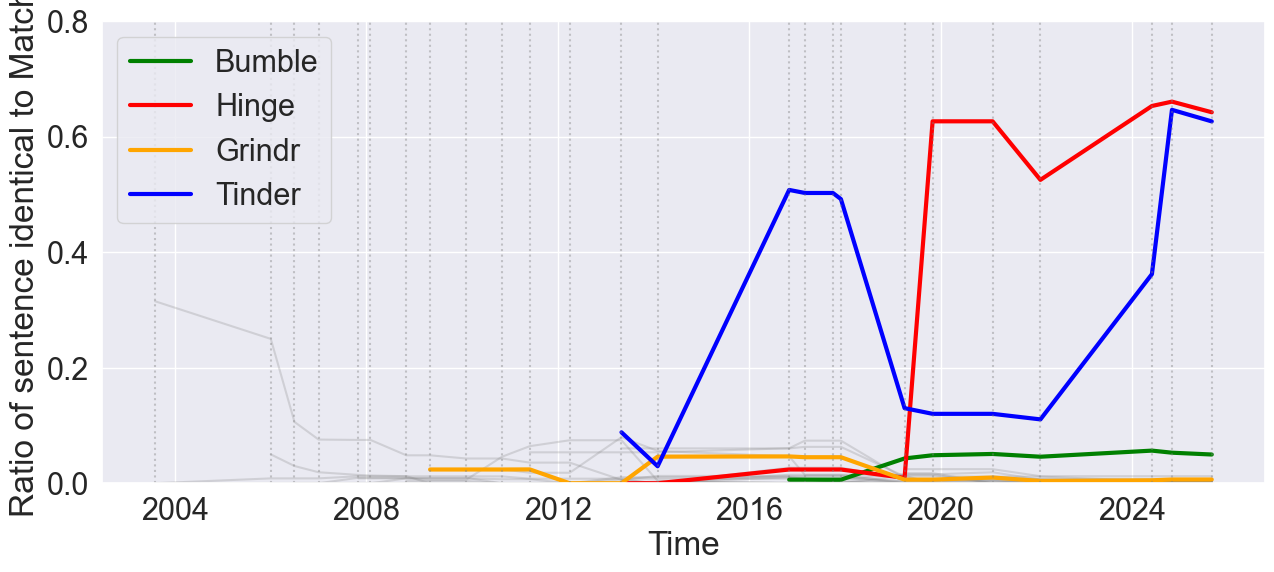

In [66]:


ax = pivot.plot(legend=False, figsize=(15,6), color=['grey'],  alpha=.25, ylim=(.0, .8))
for col,p in compare_to:
    pivot[p].plot(legend=True,  color=col, alpha=1., ax=ax, linewidth=3)
#     for xc in metadata[metadata.platform==p].date.unique():
#         if xc >= dfs.date.min() and xc <= dfs.date.max():
#             ax.axvline(x=xc, color=col, linestyle='--', alpha=.4)
        #ax.axvline(x=xc, color=col, linestyle='--', alpha=.2)

for xc in metadata[metadata.platform==platform_target].date.unique():
        if xc >= dfs.date.min() and xc <= dfs.date.max():
            ax.axvline(x=xc, color='grey', linestyle=':', alpha=.4)
        #ax.axvline(x=xc, color=col, linestyle='--', alpha=.2)

ax.set(
    xlabel="Time",
    ylabel=f"Ratio of sentence identical to {platform_target}",
)

conv = ax.get_figure()
conv.savefig(f"figures/jels/Figure_13.png", dpi=300, bbox_inches='tight')


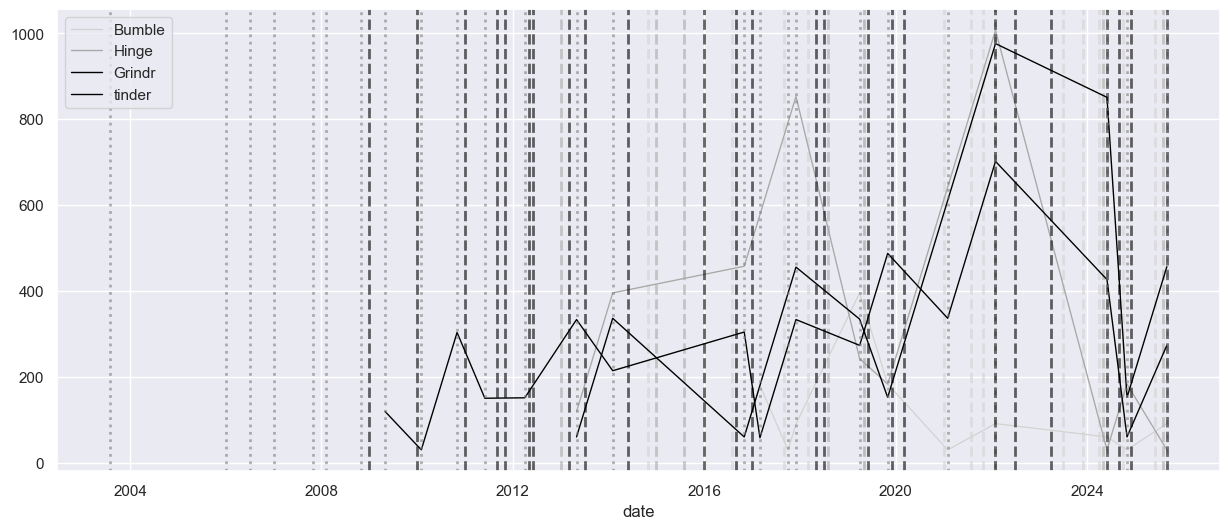

In [140]:
pivot = dfs[dfs.platform.isin([p for _, p in compare_to])].pivot_table(index=['date'], 
            columns=['platform'], values='date_gap')

ax = pivot.plot(legend=False, figsize=(15,6), color=['white'],  alpha=.25)
for col,p in compare_to:
    pivot[p].plot(legend=True,  color=col, alpha=1., ax=ax, linewidth=1)
    for xc in metadata[metadata.platform==p].date.unique():
        if xc >= dfs.date.min() and xc <= dfs.date.max():
            ax.axvline(x=xc, color=col, linestyle='--', alpha=.6,linewidth=2)
        #ax.axvline(x=xc, color=col, linestyle='--', alpha=.2)

for xc in metadata[metadata.platform==platform_target].date.unique():
        if xc >= dfs.date.min() and xc <= dfs.date.max():
            ax.axvline(x=xc, color='grey', linestyle=':', alpha=.6,linewidth=2)

(0.0, 0.8)

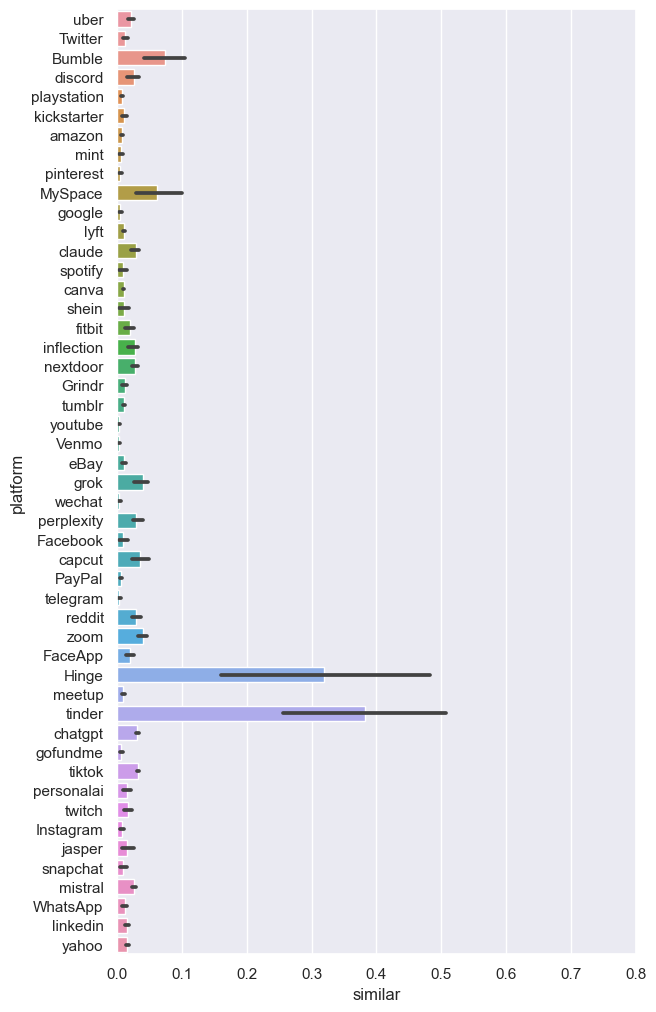

In [ ]:
# sns.set(rc={'figure.figsize':(6.7,12.27)})
# axes =sns.barplot(y='platform',x='similar',data=dfs )
# axes.set_xlim(0,.8)

<Axes: xlabel='date'>

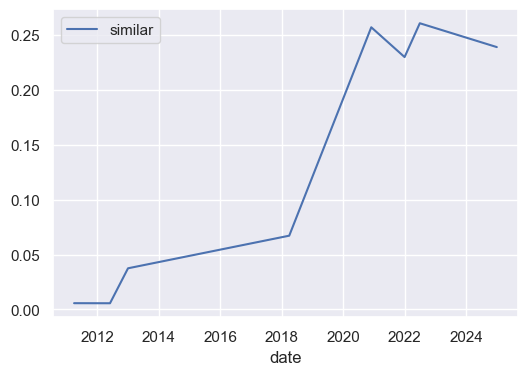

In [ ]:
# platform_t = 'instagram'
# platform_c = 'fb'

# # platform_t = 'YouTube'
# # platform_c = 'Google'

# # platform_t = 'Venmo'
# # platform_c = 'PayPal'
# results[platform_t][platform_c][['date','similar']].plot(x='date',y='similar',kind='line',figsize=(6,4))


In [ ]:
rows = []
for i,j in tqdm(results.items()):
    for k,v in j.items():
        try:
            # try to figure out why this exception occurs
            rows.append([i,k,list(v['mean'].values)])
        except Exception as  e:
            print(i,k,e)
            continue
conv_df = pd.DataFrame(rows,columns=['source','target','mean'])


In [ ]:
# sims = [s for a in  
#            conv_df[(conv_df.source=='Twitter') & (conv_df.target.isin(['FB', 'Instagram','LinkedIn']))]['mean'].values
#            for s in a
#            ]
# pd.Series(sims).plot(kind='density', color='blue', alpha=.5)

# sims = [s for a in  
#            conv_df[(conv_df.source=='FB') & (conv_df.target.isin(['Twitter', 'Instagram','LinkedIn']))]['mean'].values
#            for s in a
#            ]
# pd.Series(sims).plot(kind='density', color='blue', alpha=.5)

# sims = [s for a in  
#            conv_df[(conv_df.source=='Instagram') & (conv_df.target.isin(['Twitter', 'FB','LinkedIn']))]['mean'].values
#            for s in a
#            ]
# pd.Series(sims).plot(kind='density', color='blue', alpha=.5)

# sims = [s for a in  
#            conv_df[(conv_df.source=='LinkedIn') & (conv_df.target.isin(['Twitter', 'FB','Instagram']))]['mean'].values
#            for s in a
#            ]
# pd.Series(sims).plot(kind='density', color='blue', alpha=.5)

# sims = [s for a in  
#            conv_df[(conv_df.source=='Twitter') & (conv_df.target.isin(['PayPal', 'Venmo']))]['mean'].values
#            for s in a
#            ]
# pd.Series(sims).plot(kind='density',color='orange', alpha=.5)

# sims = [s for a in  
#            conv_df[(conv_df.source=='FB') & (conv_df.target.isin(['PayPal', 'Venmo']))]['mean'].values
#            for s in a
#            ]
# pd.Series(sims).plot(kind='density',color='orange', alpha=.5)

# sims = [s for a in  
#            conv_df[(conv_df.source=='Instagram') & (conv_df.target.isin(['PayPal', 'Venmo']))]['mean'].values
#            for s in a
#            ]
# pd.Series(sims).plot(kind='density',color='orange', alpha=.5)

# sims = [s for a in  
#            conv_df[(conv_df.source=='LinkedIn') & (conv_df.target.isin(['PayPal', 'Venmo']))]['mean'].values
#            for s in a
#            ]
# pd.Series(sims).plot(kind='density',color='orange', alpha=.5)

## Get similar sentences across platforms

In [67]:
# platform_t,platform_c = 'Google','YouTube'
# threshold = .875

# dates_t = sorted(metadata[metadata.platform==platform_t].date.unique())
# dates_c = sorted(metadata[metadata.platform==platform_c].date.unique())
# resultList = []

# for i,d in enumerate(dates_t):
#         days_delta = [(dc,(dc - d).days) for dc in dates_c]
#         dc, days = negative_closest_to_zero(days_delta)
#         if dc:

#             metadata[(metadata.date == dc) & (metadata.platform==platform_c)]

#             idx_1 = list(metadata[(metadata.platform==platform_t) & (metadata.date ==d)].index)
#             idx_2 = list(metadata[(metadata.platform==platform_c) & (metadata.date ==dc)].index)
#             #print(i,len(idx_1),len(idx_2),d,dc, days)
#             mult = 1 - sp.distance.cdist(embeddings[idx_1,:], embeddings[idx_2,:], 'cosine')
#             # x = np.apply_along_axis(np.max,0,mult)
#             # x_sent = np.array(idx_2)[np.where(x > threshold)[0]]

#             # y = np.apply_along_axis(np.max,1,mult)
#             # y_sent = np.array(idx_1)[np.where(y  > threshold)[0]]
            
#             for k,l in list(zip(*np.where(mult > threshold))):
#                 resultList.append(
#                     [d,dc,
#                     mult[k,l],
#                     metadata.iloc[idx_1[k]].platform,
#                     metadata.iloc[idx_1[k]].sentence,
#                     metadata.iloc[idx_2[l]].platform,
#                     metadata.iloc[idx_2[l]].sentence,])
     

In [68]:
# df_results = pd.DataFrame(resultList, columns=[f'date_1_{platform_t}',f'date_2_{platform_c}','similar','platform_t','sentence_t','platform_c','sentence_c'])
# df_results.shape

In [69]:
# df_results.similar.plot(kind='hist',bins=100)

In [ ]:
# dfs = []
# for s,e in [(0.9,0.95),(0.95,0.975)]: # (0.8,0.9),
#     dfs.append(df_results[df_results.similar.between(s,e)].sample(10))
# dfs = pd.concat(dfs, axis=0, ignore_index=True)
# dfs['label'] = 0
# dfs.to_csv('pairs_to_annotate_round_2.csv',index=False)

In [ ]:
# df_results[df_results.similar >= .8].to_csv('similar_sentences_Google_Google_80.csv',index=False)

In [ ]:
# df_results.sort_values(by='similar',ascending=False).drop_duplicates(subset=['date_1_FB','date_2_Instagram','sentence_t'],keep='first')

In [ ]:
# df_results.groupby('date_1_FB')['platform_t'].size().plot()

# Fin.